In [5]:
# Current fixed-candidate pipeline configuration.
%reload_ext autoreload
%autoreload 2
%cd ~/erc-src/cuneiform-ocr-sign-alignment-worktree
%env PATH=$HOME/.local/bin:$PATH

import os

import sign_alignment.pipeline as pp
from sign_alignment.data_source import LocalDataSource
from sign_alignment.detector import ModelConfig, TabletImageDetector
from sign_alignment.visualizer import ColorConfig

ANNOTATIONS_DIR = os.path.expanduser(
    "~/erc-work-data/data-of-cuneiform-ocr-data/filtered_annotations"
)
CONFIG_FILE = "configs/detr.py"
CHECKPOINT_FILE = os.path.expanduser(
    "~/erc-work-data/retrained_models/detr-173/epoch_1000.pth"
)
SCORE_THRESHOLD = 0.0
OUTPUT_DIR = "alignment_results"

/dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree
env: PATH=$HOME/.local/bin:$PATH


/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/dssuser/cuneiform-ocr/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [6]:
# Initialize the detector and shared pipeline context.
model_config = ModelConfig(
    config_file=CONFIG_FILE,
    checkpoint_file=CHECKPOINT_FILE,
    device="auto",
)
if "tablet_detector" not in globals() or getattr(tablet_detector, "model", None) is None:
    tablet_detector = TabletImageDetector(
        default_score_threshold=SCORE_THRESHOLD,
        model_config=model_config,
        is_crop_itself=False,
        use_sahi=True,
        box_slice_ratio = 0.2
    )
else:
    print("Reusing existing tablet_detector instance.")

context = pp.CropContext(
    tablet_detector=tablet_detector,
    local_source=LocalDataSource(ANNOTATIONS_DIR),
    color_config=ColorConfig,
    output_dir=OUTPUT_DIR,
    task_type="debug",
)
runner = pp.Runner(context, pp.VisOptions(info=True, display=True, save=True))


Loading model...
Using device: cuda:0
Loads checkpoint by local backend from path: /home/dssuser/erc-work-data/retrained_models/detr-173/epoch_1000.pth
Found 947 fragments with both image and annotation


Processing sample: K.4426
Ground truth sign boxes: 989
  Non-sign GT boxes hidden: 2
  Text lines: 103, total signs: 1115
  Unfiltered: 1378 signs, broken removed: 263
✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/initial/debug_K.4426_gt.jpg


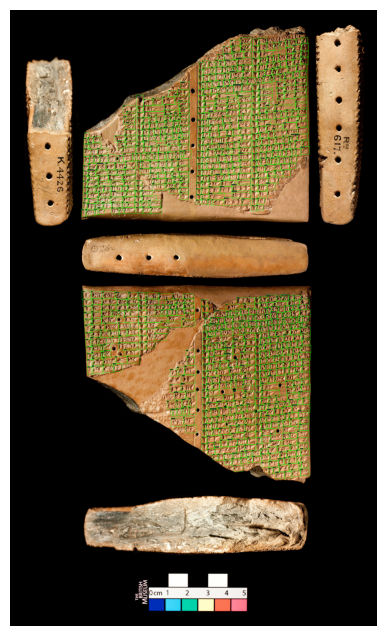

Performing prediction on 42 slices.
Performing prediction on 18 slices.
Performing prediction on 4 slices.
Performing prediction on 1 slices.
Performing prediction on 42 slices.
Performing prediction on 1 slices.
Performing prediction on 10 slices.
Total detections (full image): 2027
Sub-image detections: 973
Crop info (img_idx=4): x=859, y=3308, w=2778, h=2415
✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/initial/debug_K.4426_det.jpg
✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/initial/debug_K.4426_sub_image.jpg


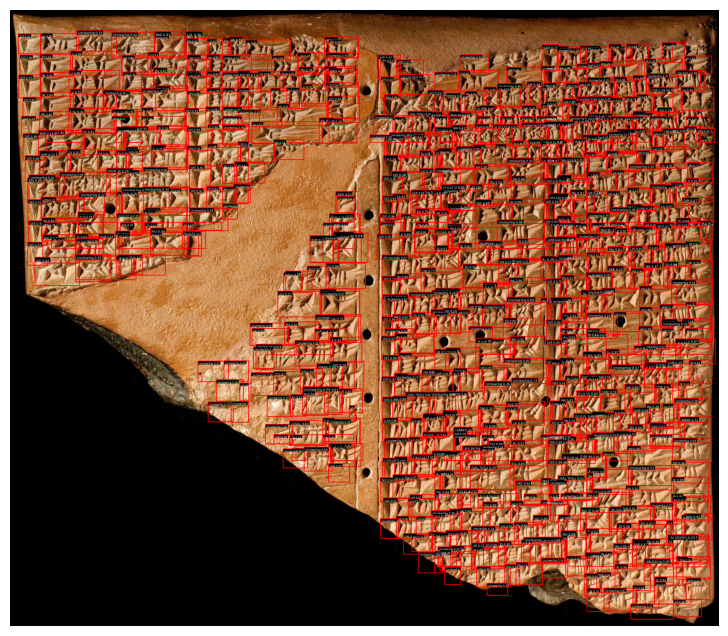

GT sign boxes (full image): 989
GT sign boxes (sub-image):  488
Non-sign GT boxes hidden (full/sub-image): 2/1
✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/initial/debug_K.4426_sub_image_gt.jpg


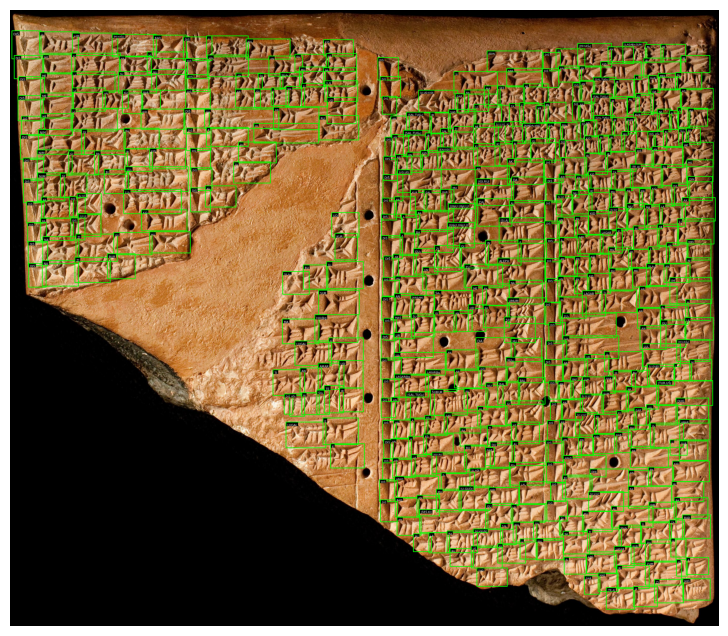

Full image shape: (7434, 4417, 3)
Sub-image shape:  (2415, 2778, 3)
Average detected sign  width: 101.01
Average detected sign height: 83.12
SubTablet 'crop_4': image shape=(2415, 2778, 3), offset_in_parent=(859, 3308), mask=available
Boxes 'text':
  1115 signs,
  image shape: (2415, 2778, 3)
  avg_width: 101.01, avg_height: 83.12
Text rows: 103, signs: 1115
=== Row Detection Results ===
Average sign size: 92.06 px, detected 45 rows, 973 signs
  Hough row angles: -11.8 to 1.1 deg, global score peak: -7.0 deg, baselines: 45
  Curve reselection: 62 initial, 27 robust-fit outliers, ±6.0 deg window
  Row 0: 15 boxes, angle: 1.1 deg
  Row 1: 28 boxes, angle: -1.1 deg
  Row 2: 4 boxes, angle: -3.0 deg
  Row 3: 18 boxes, angle: -1.2 deg
  Row 4: 26 boxes, angle: -3.5 deg
  Row 5: 27 boxes, angle: -4.7 deg
  Row 6: 11 boxes, angle: 1.0 deg
  Row 7: 20 boxes, angle: -5.0 deg
  Row 8: 28 boxes, angle: -0.1 deg
  Row 9: 23 boxes, angle: -2.7 deg
  Row 10: 59 boxes, angle: -3.9 deg
  Row 11: 25 bo

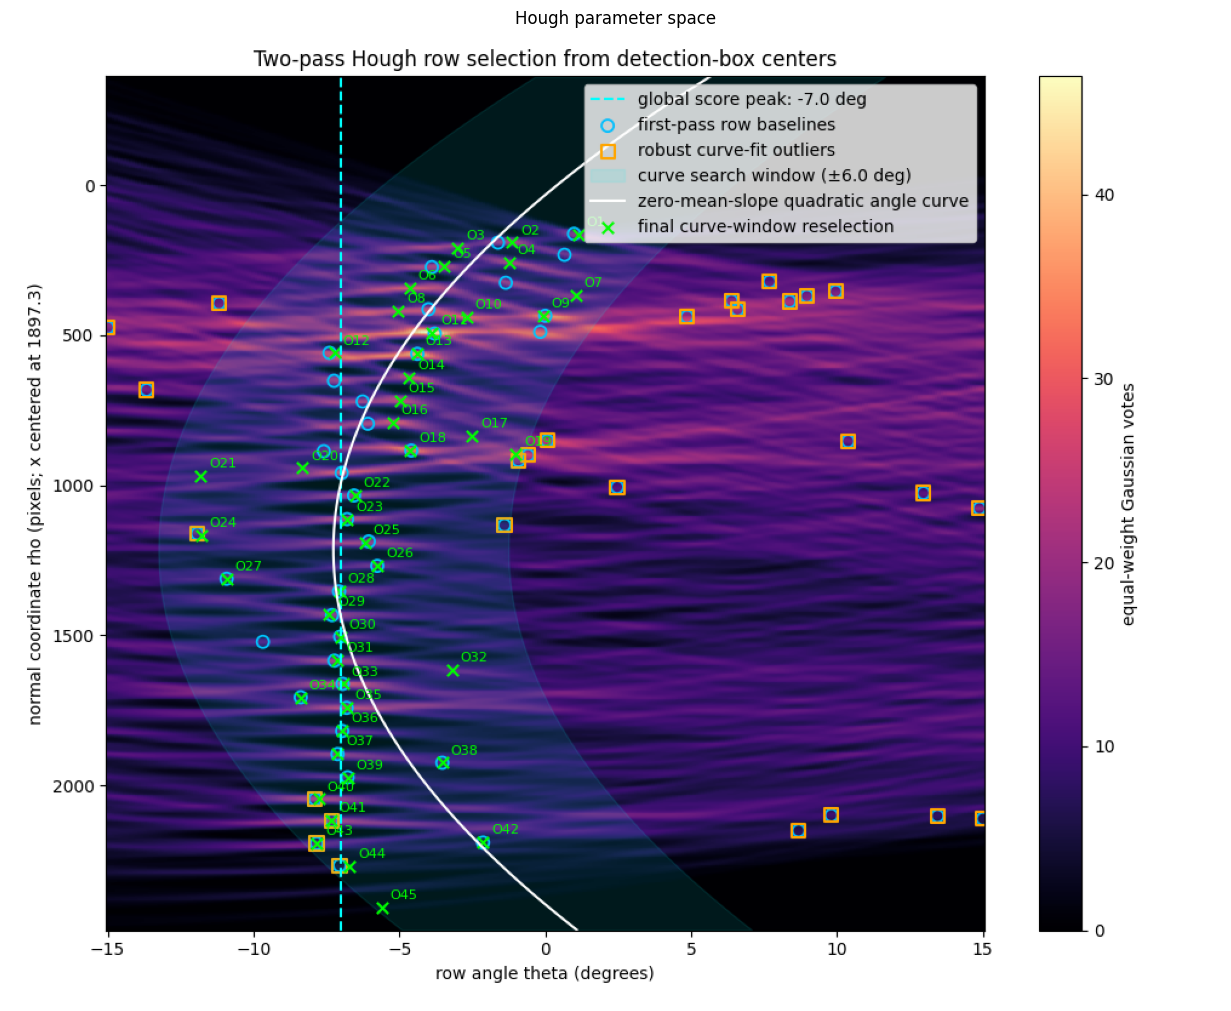

✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/row_detection/debug_K.4426_hough_parameter_space.jpg


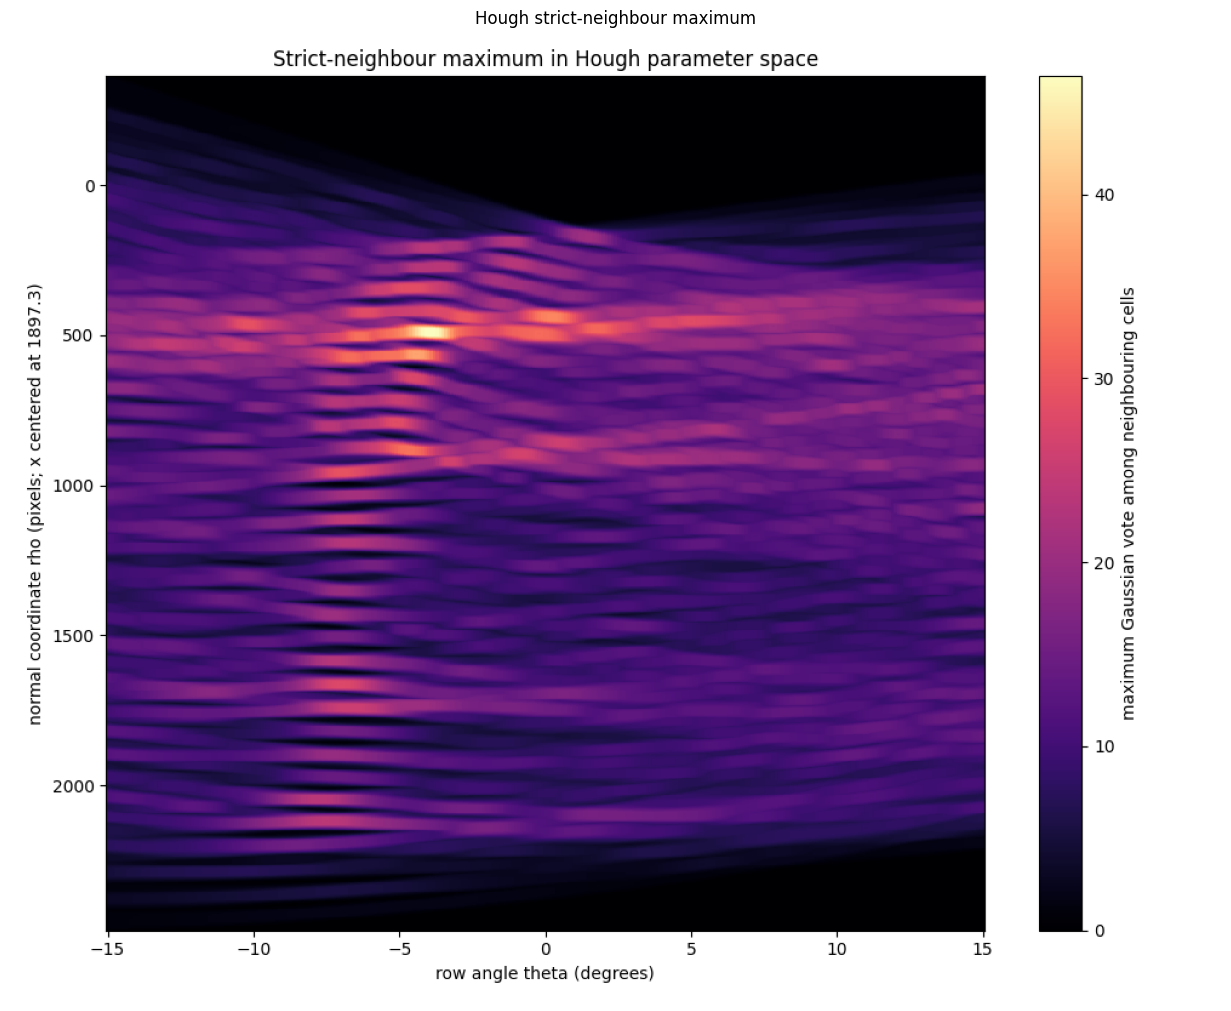

✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/row_detection/debug_K.4426_hough_strict_neighbour_max.jpg


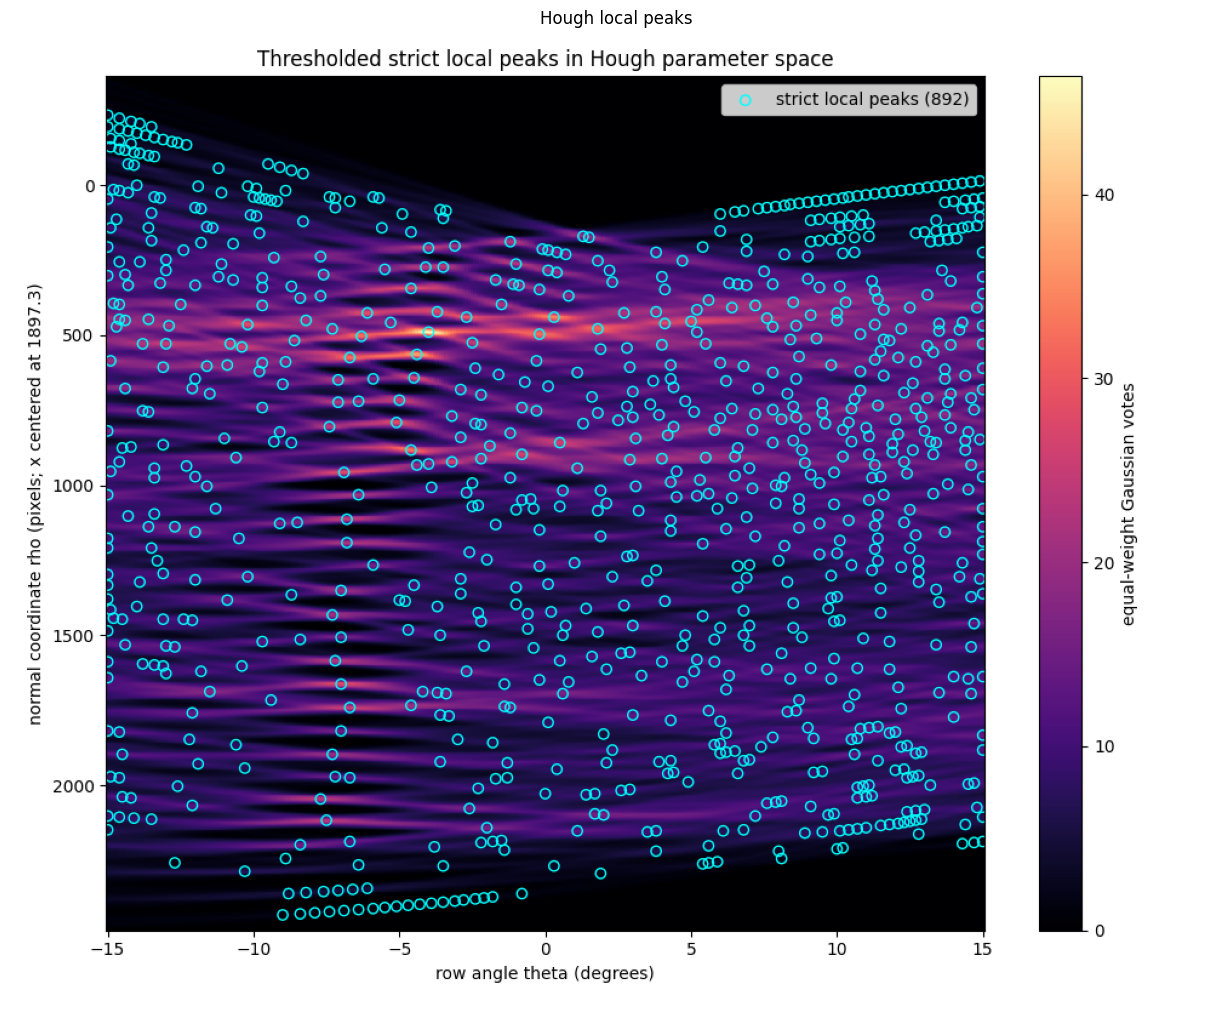

✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/row_detection/debug_K.4426_hough_peaks.jpg


In [7]:
# Initialize data that stays fixed across optimization iterations.
SAMPLE_NAME = "NBC.4020"
SAMPLE_NAME = "YBC.7794"
SAMPLE_NAME = "HS.2020"
SAMPLE_NAME = "BM.34110"
SAMPLE_NAME = "CBS.1516"
SAMPLE_NAME = "K.4426"
CROP_INDEX = 4
runner.choose_sample(name=SAMPLE_NAME)
runner.choose_crop(CROP_INDEX)
runner.run([
    pp.Step("Load data", pp.load_data, pp.vis_loaded_data),
    pp.Step("Detect signs", pp.detect_signs, pp.vis_detections),
    pp.Step("Transform GT to crop", pp.transform_gt_to_crop, pp.vis_crop_ground_truth),
    pp.Step("Detection statistics", lambda _: None, pp.vis_detection_statistics),
    pp.Step("Create box sets", pp.create_box_sets, pp.vis_box_sets),
    pp.Step("Detect rows", pp.detect_rows, pp.vis_detected_rows_info),
    pp.Step("Unload detector", pp.unload_detector),
])


In [8]:
runner.context.state.candidate_rows

BoxRows(boxes=['NE', 'AN', 'LU₂', 'UD', 'A', 'U₂', 'TI', 'KI', 'LA', 'BAD', 'LA', 'TI', 'AN', 'NU', 'NA', 'NA', '|I.A|', 'SUR', 'NA', 'RI', 'AN', '|SAL.TUG₂|', 'AN', 'ŠE', 'AN', 'IM', 'UD', 'DIŠ', 'KI', 'RI', 'ŠU', 'KI', 'KUR', 'DIŠ', 'DIŠ', 'AN', 'LU₂', 'DIŠ', 'KI', 'ZA', 'MU', 'RU', 'ŠU', 'MA', 'ŠU', 'AN', 'DI', 'KI', 'KI', 'UD', 'DIŠ', 'GIŠ', 'AN', 'DIŠ', 'GAR', 'IGI', 'DIŠ', 'KUR', 'DIŠ', 'KI', 'NE', 'ŠU', 'DIŠ', 'U₂', 'AN', 'DU', 'DIŠ', 'BI', 'DIŠ', 'KU₃', 'SAG', 'NA', 'AN', 'LU₂', 'A', 'DIŠ', 'BU', 'DA', 'MU', 'KI', 'DIŠ', 'DIŠ', 'DIŠ', 'AN', 'AN', 'DIŠ', 'LU₂', 'DIŠ', 'UnclearSign', 'LA', 'DIŠ', 'DIŠ', 'A', 'DIŠ', 'DIŠ', 'LA', 'GAR', 'IR', 'DIŠ', 'DIŠ', 'UD', 'E', 'DIŠ', '|U.U.U|', 'UD', 'AN', 'RA', 'KID', 'A', 'LA', 'DIŠ', 'DIŠ', '|U.U.U|', 'AN', 'DIŠ', 'DIŠ', 'DIŠ', 'U', 'E₂', 'RA', 'NA', 'E', 'ZI', 'LU₂', 'ŠU', 'AN', 'MA', 'TUK', 'MA', 'GI', 'LI', 'GI', 'UnclearSign', 'DIŠ', 'DIŠ', 'BAD', 'KID', 'UD', 'DIŠ', 'DIŠ', 'MU', 'AN', 'DIŠ', 'A', 'TI', 'E', 'AN', 'DIŠ', 'KID', 'ME', 

In [9]:
print(runner.context.state.tablet.img.shape)
print(runner.context.state.det_boxes.avg_size)
print(runner.context.state.det_boxes.avg_height)
print(runner.context.state.det_boxes.avg_width)


(2415, 2778, 3)
92.92401514906065
84.48160287949189
101.36642741862941


=== Row Matching ===
Optimize rows: 45, Text rows: 103, Matched: 31
  Text row 50 (5 signs) -> Optimize row 0 (15 signs)
    Text: UnclearSign |TUR.UŠ| DIŠ AN UnclearSign
    Optimize:  DIŠ U₂ UnclearSign |HI×AŠ₂| UnclearSign...
  Text row 51 (1 signs) -> Optimize row 1 (28 signs)
    Text: |TUR.UŠ|
    Optimize:  DIŠ AŠ ME LI HA...
  Text row 52 (2 signs) -> Optimize row 2 (4 signs)
    Text: DIŠ UnclearSign
    Optimize:  DIŠ ŠU₂ MEŠ UnclearSign
  Text row 53 (13 signs) -> Optimize row 3 (18 signs)
    Text: DIŠ |HI×AŠ₂| AN A EDIN...
    Optimize:  DIŠ ME LI AŠ₂ ŠU...
  Text row 54 (10 signs) -> Optimize row 4 (26 signs)
    Text: DIŠ AN SI KAK DIŠ...
    Optimize:  DIŠ ME LI AN UnclearSign...
  Text row 55 (19 signs) -> Optimize row 5 (27 signs)
    Text: DIŠ AN PAP |U.UD.KID| GAR...
    Optimize:  U₂ LU₂ LUGAL UnclearSign AN...
  Text row 56 (20 signs) -> Optimize row 7 (20 signs)
    Text: DIŠ AN |SAL.TUG₂| IB SAG...
    Optimize:  UnclearSign |SAL.TUG₂| IB LU TU...
  Text row 57 

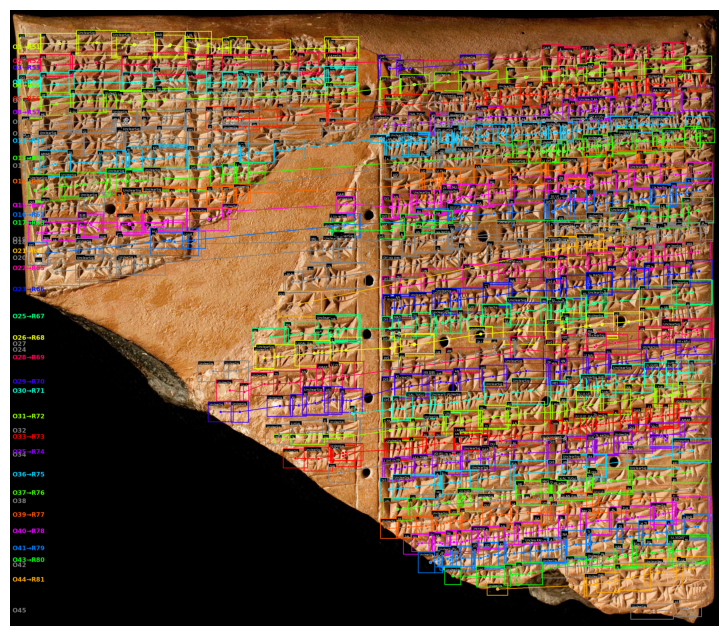

✓ Saved to: /dss/pn34bu-dss-0000/src/cuneiform-ocr-sign-alignment-worktree/alignment_results/K.4426/iter_001/debug_K.4426_optimize_rows.jpg
=== Within-Row Sign Matching ===
Text row 50 -> Optimize row 0: 5 text, 15 optimize, 5 matched, 1 candidate-backed anchors
  1. Text[0]=UnclearSign <-> Optimize[4]=UnclearSign
  2. Text[1]=|TUR.UŠ| <-> Optimize[11]=SAL
  3. Text[2]=DIŠ <-> Optimize[12]=U₂
  4. Text[3]=AN <-> Optimize[13]=KID
  5. Text[4]=UnclearSign <-> Optimize[14]=ŠID
Text row 51 -> Optimize row 1: 1 text, 28 optimize, 1 matched, 0 candidate-backed anchors
  1. Text[0]=|TUR.UŠ| <-> Optimize[27]=TUK
Text row 52 -> Optimize row 2: 2 text, 4 optimize, 2 matched, 2 candidate-backed anchors
  1. Text[0]=DIŠ <-> Optimize[0]=DIŠ
  2. Text[1]=UnclearSign <-> Optimize[3]=UnclearSign
Text row 53 -> Optimize row 3: 13 text, 18 optimize, 13 matched, 3 candidate-backed anchors
  1. Text[0]=DIŠ <-> Optimize[0]=DIŠ
  2. Text[1]=|HI×AŠ₂| <-> Optimize[1]=ME
  3. Text[2]=AN <-> Optimize[2]=LI
  4.

In [ ]:
# Re-run the same optimization batch; every pass starts from the previous result.
candidate_config = pp.CandidateAttractionConfig()
iteration_steps = [
    pp.Step("Match rows", pp.match_rows, pp.vis_row_matches),
    pp.Step("Visualize optimization rows", lambda _: None, pp.vis_optimize_rows),
    pp.Step("Match signs", pp.match_signs_in_rows, pp.vis_sign_matches),
    pp.Step("Align text rows", pp.align_text_rows, pp.vis_aligned_rows),
    pp.Step(
        "Candidate attraction",
        lambda ctx: pp.run_candidate_attraction(ctx, candidate_config),
        pp.vis_candidate_attraction,
    ),
    pp.Step(
        "Candidate alignment diagnostic",
        pp.build_candidate_sign_match_info,
        pp.vis_candidate_alignment_diagnostic,
    ),
    pp.Step(
        "Candidate comparison",
        lambda _: None,
        pp.vis_candidate_results_comparison,
    ),
]

NUM_OPTIMIZATION_ITERATIONS = 1
for _ in range(NUM_OPTIMIZATION_ITERATIONS):
    runner.run(iteration_steps, advance_iteration=True)
candidate_run = pp.get_candidate_run(context)


In [ ]:
# Inspect assignments, including position-only wrong-label matches.
records = pp.candidate_attraction_records(context)
try:
    import pandas as pd

    candidate_table = pd.DataFrame(records)
    display(candidate_table[[
        "text_row_idx", "optimize_row_idx", "candidate_row_idx",
        "text_idx", "sign_name", "input_status",
        "output_status", "candidate_idx", "detector_labels",
        "class_support", "soft_probability", "null_probability",
        "included_in_result", "movement_px",
    ]])
except ImportError:
    candidate_table = records
    display(candidate_table[:20])

position_only = [
    row for row in records
    if row["output_status"] == "candidate" and row["class_support"] <= 0.0
]
print(f"Optimization iteration: {candidate_run.iteration}")
print(f"Position-only/wrong-label candidate matches: {len(position_only)}")


,text_row_idx,optimize_row_idx,candidate_row_idx,text_idx,sign_name,input_status,output_status,candidate_idx,detector_labels,class_support,soft_probability,null_probability,included_in_result,movement_px
0,50,0,0,0,UnclearSign,fully_matched,anchor,3.0,"(UnclearSign, |HI×AŠ₂|)",0.618664,1.000000,0.000000,True,2.538277
1,50,0,0,1,|TUR.UŠ|,diff_matched,candidate,4.0,"(BAD,)",0.000000,0.456554,0.000048,True,37.124406
2,50,0,0,2,DIŠ,diff_matched,candidate,6.0,"(ME,)",0.000000,0.258644,0.000045,True,45.681832
3,50,0,0,3,AN,diff_matched,candidate,8.0,"(I,)",0.000000,0.265168,0.000046,True,30.577632
4,50,0,0,4,UnclearSign,diff_matched,candidate,10.0,"(DIN, SAL)",0.000000,0.313039,0.000049,True,9.204561
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
407,81,44,44,2,ZI,diff_matched,candidate,2.0,"(SA,)",0.000000,0.785555,0.001139,True,4.221573
408,81,44,44,3,MEŠ,diff_matched,candidate,3.0,"(GI, HU)",0.000000,0.827311,0.001226,True,26.068778
409,82,45,45,0,UnclearSign,fully_matched,anchor,0.0,"(UnclearSign,)",0.374170,1.000000,0.000000,True,0.000000
410,82,45,45,1,IB,diff_matched,candidate,1.0,"(AŠ,)",0.000000,0.824474,0.175526,True,39.550841


Optimization iteration: 1
Position-only/wrong-label candidate matches: 164


In [ ]:
s = runner.context.state

print(s.candidate_rows)
print(s.optimize_rows)
print(s.aligned_rows)
print(s.optimize_sign_match_info)
print(s.text_sign_match_info)
print(s.optimize_to_text)


BoxRows(boxes=['NE', 'AN', 'LU₂', 'UD', 'A', 'U₂', 'TI', 'KI', 'LA', 'BAD', 'LA', 'TI', 'AN', 'NU', 'NA', 'NA', '|I.A|', 'SUR', 'NA', 'RI', 'AN', '|SAL.TUG₂|', 'AN', 'ŠE', 'AN', 'IM', 'UD', 'DIŠ', 'KI', 'RI', 'ŠU', 'KI', 'KUR', 'DIŠ', 'DIŠ', 'AN', 'LU₂', 'DIŠ', 'KI', 'ZA', 'MU', 'RU', 'ŠU', 'MA', 'ŠU', 'AN', 'DI', 'KI', 'KI', 'UD', 'DIŠ', 'GIŠ', 'AN', 'DIŠ', 'GAR', 'IGI', 'DIŠ', 'KUR', 'DIŠ', 'KI', 'NE', 'ŠU', 'DIŠ', 'U₂', 'AN', 'DU', 'DIŠ', 'BI', 'DIŠ', 'KU₃', 'SAG', 'NA', 'AN', 'LU₂', 'A', 'DIŠ', 'BU', 'DA', 'MU', 'KI', 'DIŠ', 'DIŠ', 'DIŠ', 'AN', 'AN', 'DIŠ', 'LU₂', 'DIŠ', 'UnclearSign', 'LA', 'DIŠ', 'DIŠ', 'A', 'DIŠ', 'DIŠ', 'LA', 'GAR', 'IR', 'DIŠ', 'DIŠ', 'UD', 'E', 'DIŠ', '|U.U.U|', 'UD', 'AN', 'RA', 'KID', 'A', 'LA', 'DIŠ', 'DIŠ', '|U.U.U|', 'AN', 'DIŠ', 'DIŠ', 'DIŠ', 'U', 'E₂', 'RA', 'NA', 'E', 'ZI', 'LU₂', 'ŠU', 'AN', 'MA', 'TUK', 'MA', 'GI', 'LI', 'GI', 'UnclearSign', 'DIŠ', 'DIŠ', 'BAD', 'KID', 'UD', 'DIŠ', 'DIŠ', 'MU', 'AN', 'DIŠ', 'A', 'TI', 'E', 'AN', 'DIŠ', 'KID', 'ME', 

In [ ]:
s.optimize_row_sequences

[['DIŠ',
  'U₂',
  'UnclearSign',
  '|HI×AŠ₂|',
  'UnclearSign',
  'BAD',
  'BAD',
  'ME',
  'LAL',
  'I',
  'AŠ₂',
  'SAL',
  'U₂',
  'KID',
  'ŠID'],
 ['DIŠ',
  'AŠ',
  'ME',
  'LI',
  'HA',
  'LI',
  'DIŠ',
  'ME',
  'LUGAL',
  'LU₂',
  'AN',
  'UD',
  'GU',
  'UnclearSign',
  'LA',
  'GAR',
  'AN',
  'UnclearSign',
  'SI',
  'E',
  '|HI×AŠ₂|',
  'KI',
  'TUM',
  'SI',
  'AN',
  'KI',
  'IR',
  'TUK'],
 ['DIŠ', 'ŠU₂', 'MEŠ', 'UnclearSign'],
 ['DIŠ',
  'ME',
  'LI',
  'AŠ₂',
  'ŠU',
  'MU',
  'DIŠ',
  'LAL',
  'LU₂',
  'LUGAL',
  'SU',
  '|DIŠ.DIŠ.DIŠ|',
  'AN',
  'ŠU',
  'SILA₃',
  'MU',
  'NA',
  'DIN'],
 ['DIŠ',
  'ME',
  'AN',
  'UnclearSign',
  'SAL',
  'UnclearSign',
  'RU',
  '|I.A|',
  'DIŠ',
  'AN',
  'UnclearSign',
  'UnclearSign',
  'SI',
  'TAB',
  'KAK',
  'UnclearSign',
  'DIŠ',
  'LA',
  'AN',
  'UnclearSign',
  'KUR',
  'IB',
  'KID',
  'IB',
  'NI'],
 ['DU',
  'UnclearSign',
  'MA',
  'LU',
  'UnclearSign',
  'UnclearSign',
  'AN',
  'BAL',
  'UD',
  'NA',
  'Unclear

In [ ]:
s.candidate_boxes, s.optimize_boxes

(Boxes(lenth = 973
 ['NE', 'AN', 'LU₂', 'UD', 'A', 'U₂', 'TI', 'KI', 'LA', 'BAD', 'LA', 'TI', 'AN', 'NU', 'NA', 'NA', '|I.A|', 'SUR', 'NA', 'RI', 'AN', '|SAL.TUG₂|', 'AN', 'ŠE', 'AN', 'IM', 'UD', 'DIŠ', 'KI', 'RI', 'ŠU', 'KI', 'KUR', 'DIŠ', 'DIŠ', 'AN', 'LU₂', 'DIŠ', 'KI', 'ZA', 'MU', 'RU', 'ŠU', 'MA', 'ŠU', 'AN', 'DI', 'KI', 'KI', 'UD', 'DIŠ', 'GIŠ', 'AN', 'DIŠ', 'GAR', 'IGI', 'DIŠ', 'KUR', 'DIŠ', 'KI', 'NE', 'ŠU', 'DIŠ', 'U₂', 'AN', 'DU', 'DIŠ', 'BI', 'DIŠ', 'KU₃', 'SAG', 'NA', 'AN', 'LU₂', 'A', 'DIŠ', 'BU', 'DA', 'MU', 'KI', 'DIŠ', 'DIŠ', 'DIŠ', 'AN', 'AN', 'DIŠ', 'LU₂', 'DIŠ', 'UnclearSign', 'LA', 'DIŠ', 'DIŠ', 'A', 'DIŠ', 'DIŠ', 'LA', 'GAR', 'IR', 'DIŠ', 'DIŠ', 'UD', 'E', 'DIŠ', '|U.U.U|', 'UD', 'AN', 'RA', 'KID', 'A', 'LA', 'DIŠ', 'DIŠ', '|U.U.U|', 'AN', 'DIŠ', 'DIŠ', 'DIŠ', 'U', 'E₂', 'RA', 'NA', 'E', 'ZI', 'LU₂', 'ŠU', 'AN', 'MA', 'TUK', 'MA', 'GI', 'LI', 'GI', 'UnclearSign', 'DIŠ', 'DIŠ', 'BAD', 'KID', 'UD', 'DIŠ', 'DIŠ', 'MU', 'AN', 'DIŠ', 'A', 'TI', 'E', 'AN', 'DIŠ', 'KID', 